# Federal new-hire heatmaps: grade × education by occupation

Each figure below shows **new federal hires** for one occupational series (or all occupations), broken out by **GS grade** (columns) and **education level** (rows).

**Data:** OPM/EHRI *accessions* (new hires) via the public HuggingFace dataset [`impactproject/opm-ehri-data`](https://huggingface.co/datasets/impactproject/opm-ehri-data), which mirrors [data.opm.gov](https://data.opm.gov/explore-data/data/data-downloads). Parquet is streamed remotely with DuckDB — nothing is downloaded to disk. Counts are `SUM(count)` over rows from **January 2021 onward (latest month April 2026)**.

**Everything runs off one call:** `accession_heatmap("<series code>")`. Key options: `pay_plans` (`"gs"`, `"gs+gg"`, `"all"`), `totals`, `highlight_quals`, `simple` (publication layout), and `series=None` for all occupations.

In [1]:
from ehri_heatmaps import accession_heatmap

/Users/abigailhaddad/Documents/repos/pull_usaspending/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
SERIES = {
    "2210": "IT Management",
    "1550": "Computer Science",
    "1560": "Data Science",
    "1530": "Statistics",
}

## Simplified view — for publication

Collapsed to **5 education buckets** (≤ high school · some college/associate · bachelor's/post-bach · master's/professional · doctorate) and **4 grade groups** (≤ GS-7 · GS-8–9 · GS-10–11 · GS-12+). Totals show percentages only. The **outlined** cells form the degree→grade staircase (bachelor's→GS-7, master's→GS-9, Ph.D.→GS-11; a higher degree also covers the lower groups), and the box reports the share of hires landing in any outlined cell.

### Figure A — All occupations (GS + GG), simplified

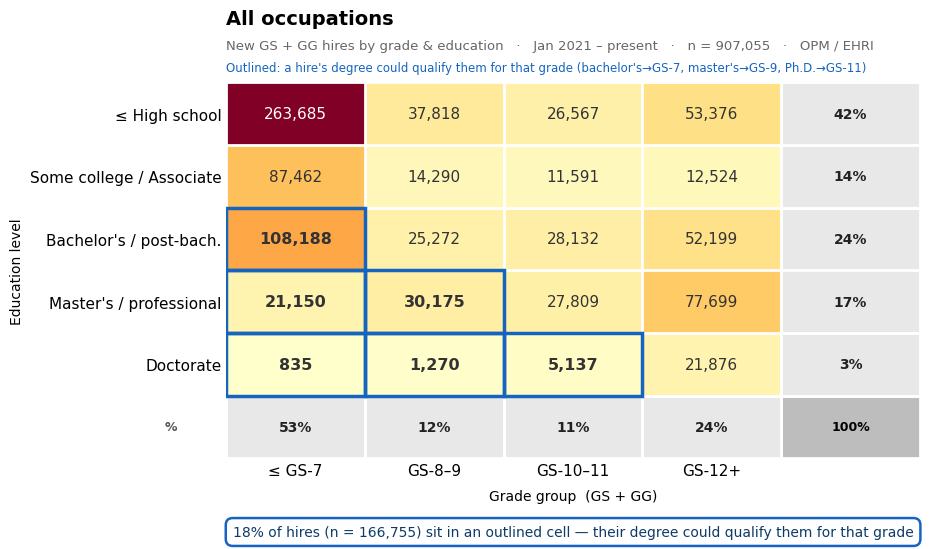

In [3]:
accession_heatmap(simple=True, highlight_quals=True);

### Figure B — 2210 (IT Management), simplified

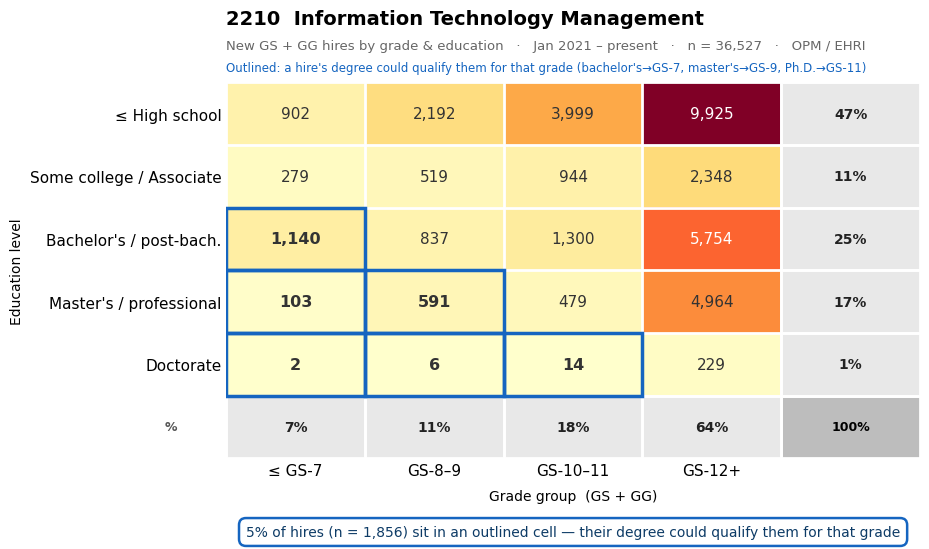

In [4]:
accession_heatmap("2210", simple=True, highlight_quals=True);

Swap in any of the other series — same call, just change the code:

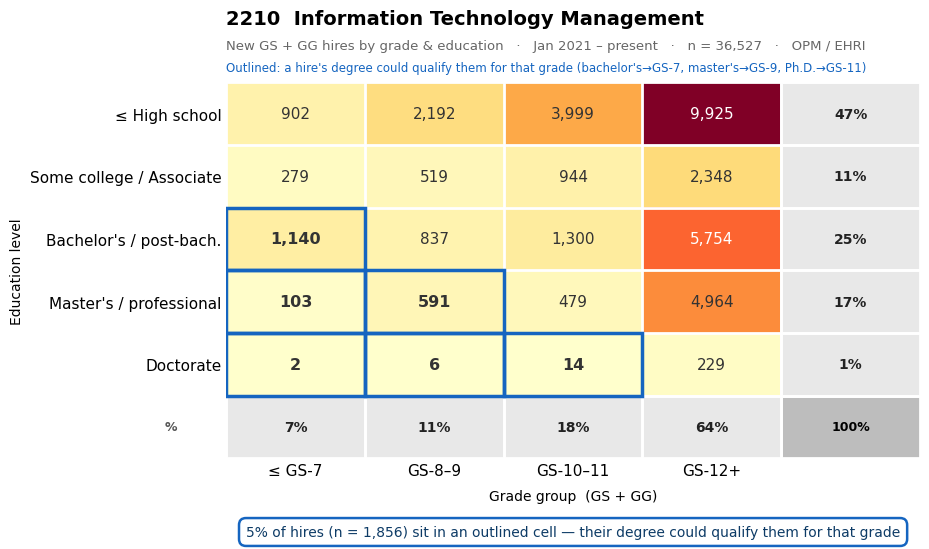

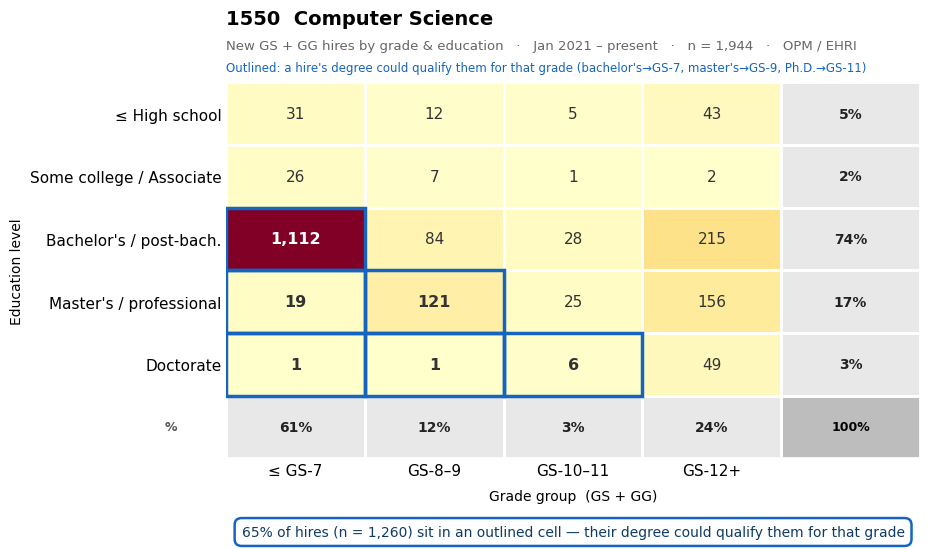

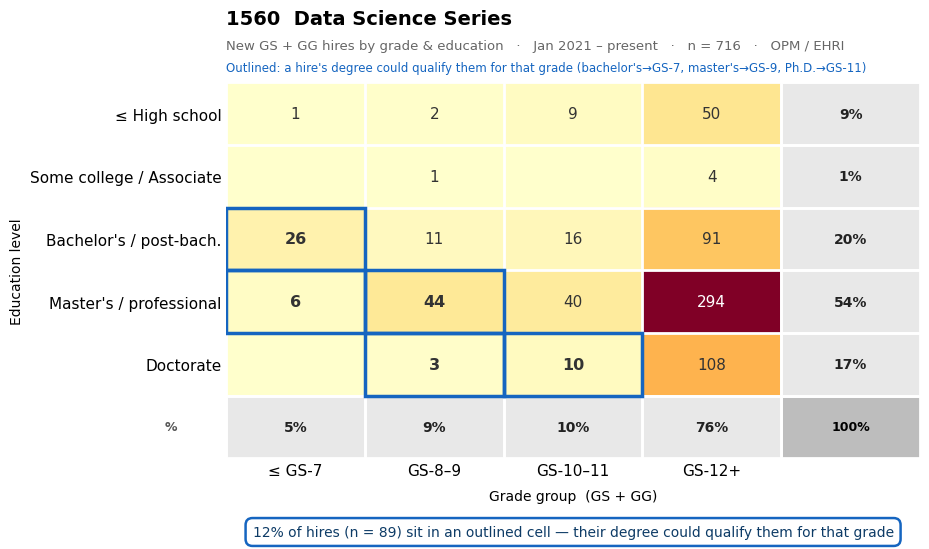

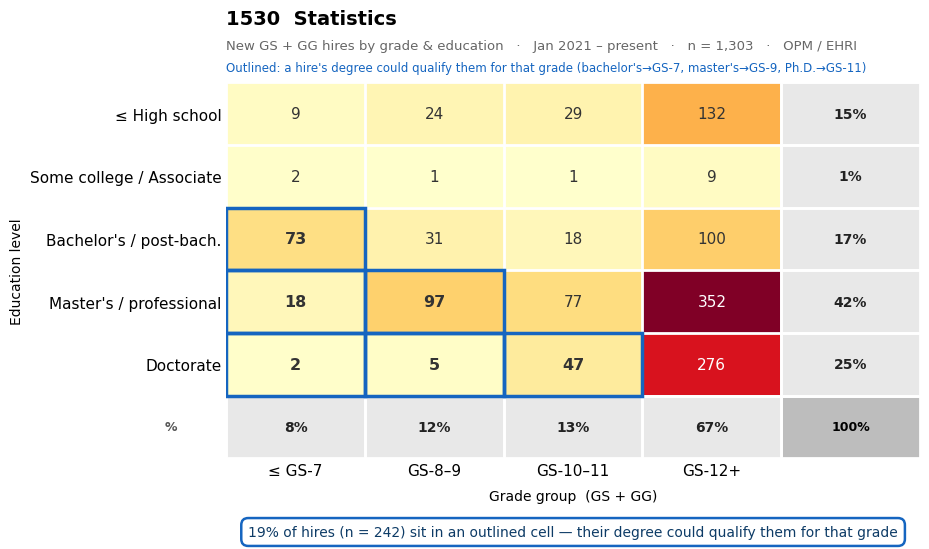

In [5]:
for code, name in SERIES.items():
    accession_heatmap(code, simple=True, highlight_quals=True)

## Detailed views

Full GS-01…GS-15 scale and the nine raw education buckets.

### GS hires only (GS-01 … GS-15)

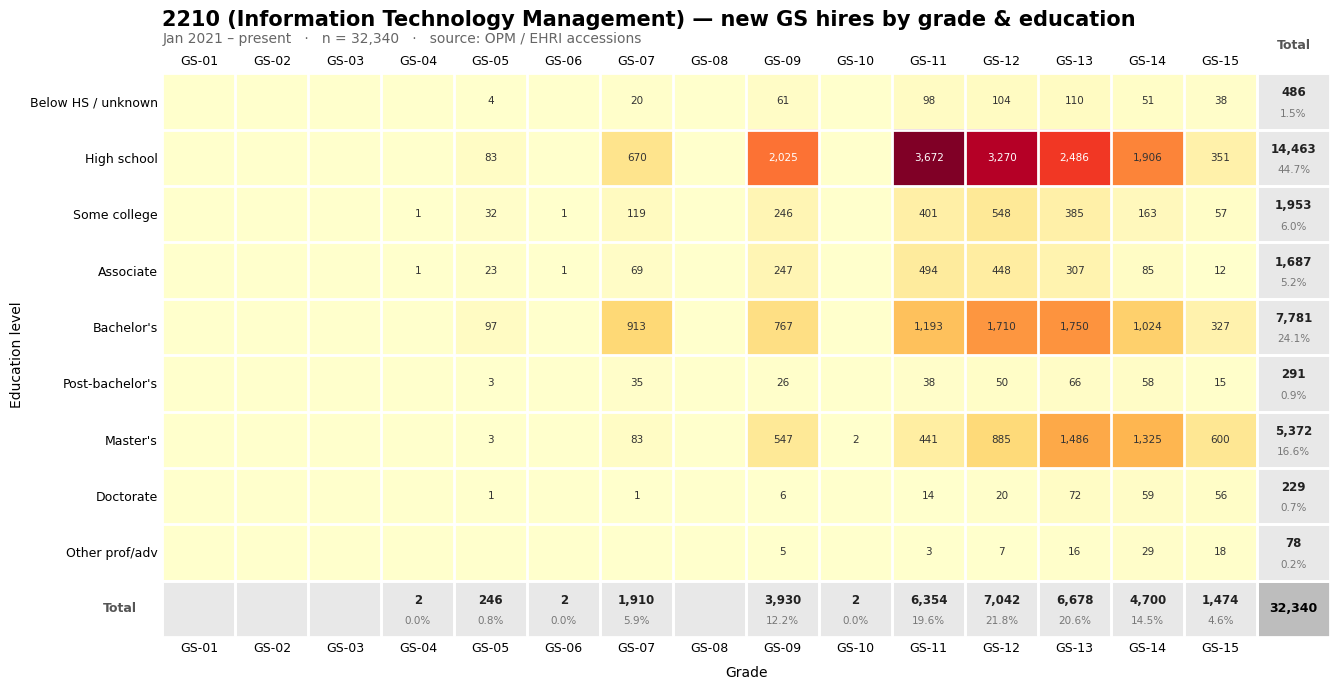

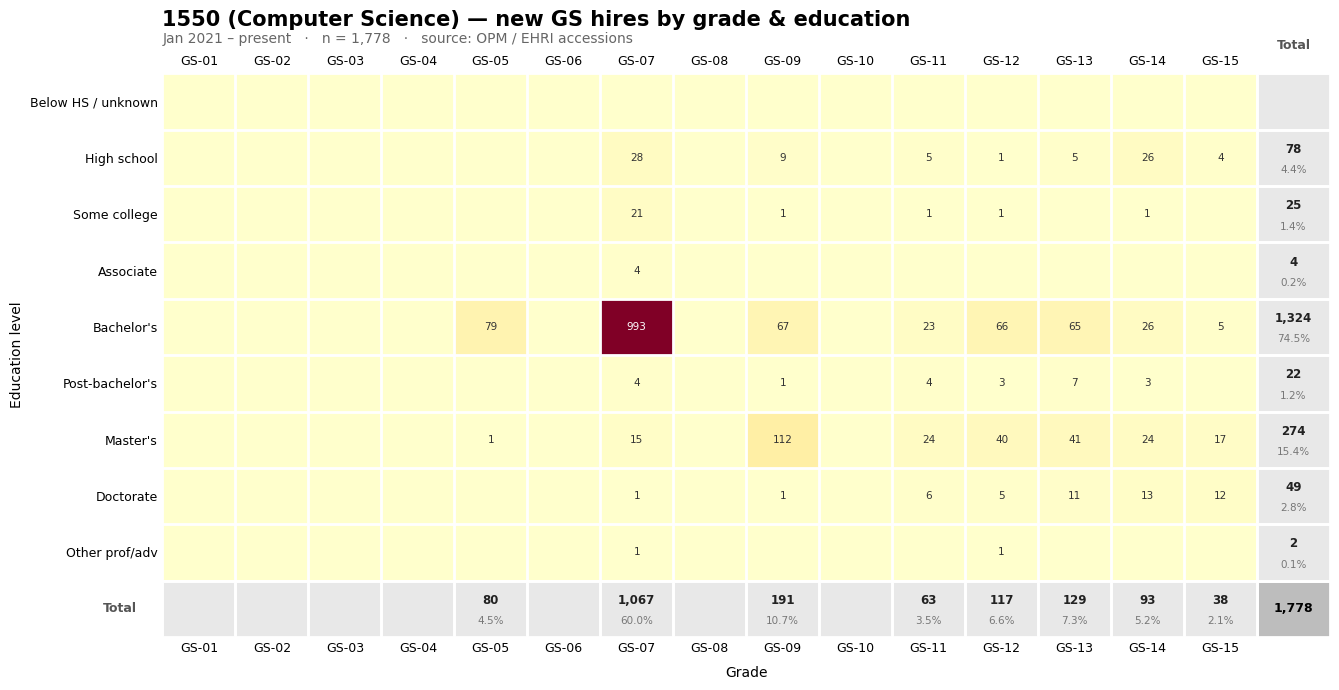

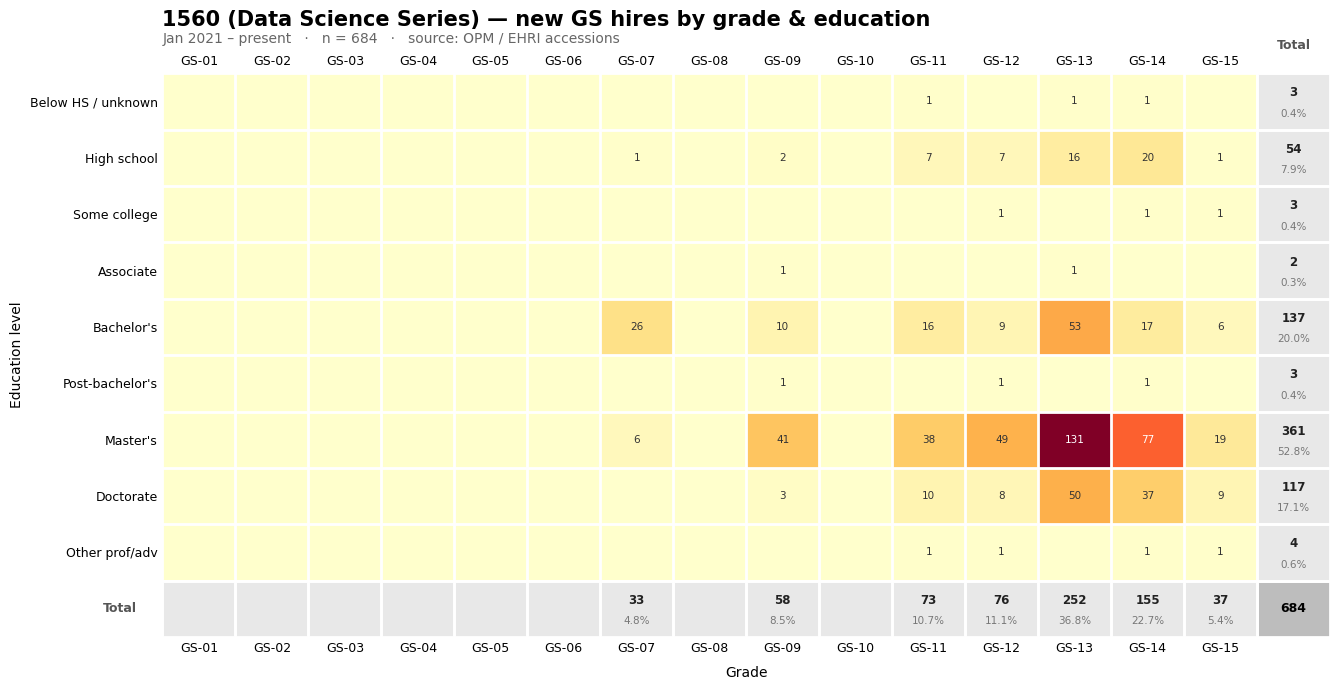

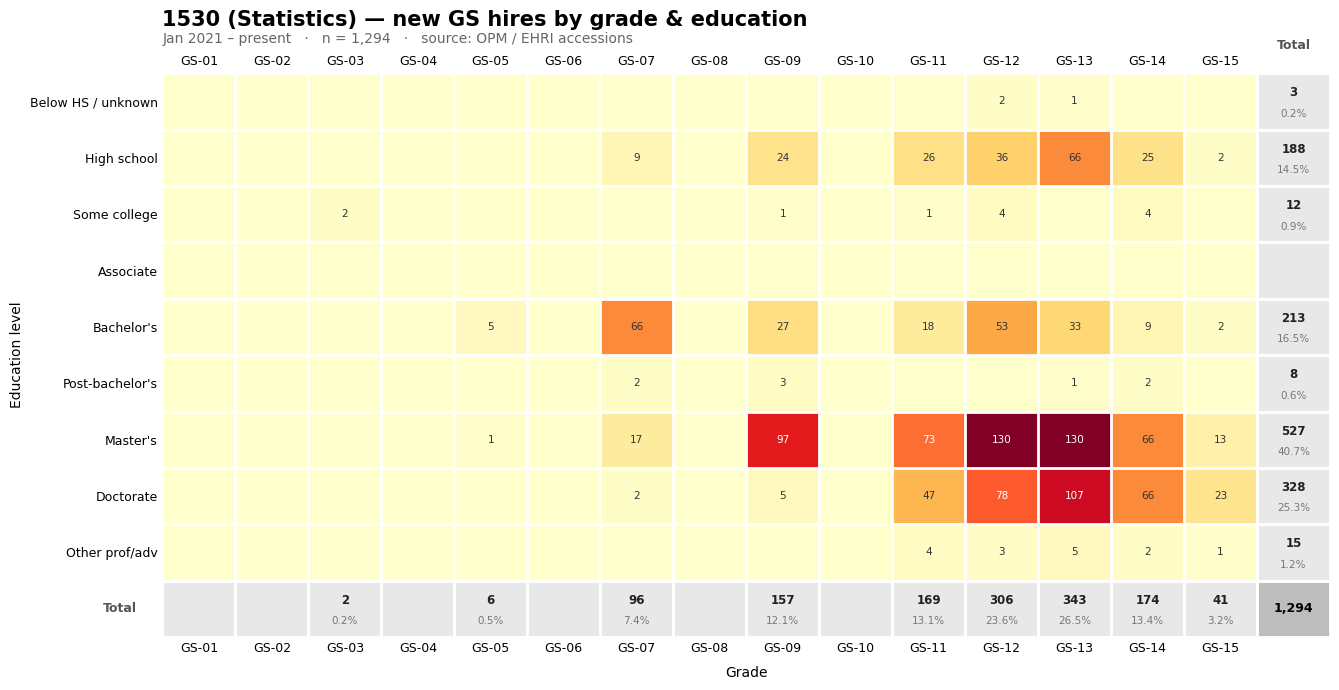

In [6]:
for code in SERIES:
    accession_heatmap(code)

### All pay plans

GS **and GG** share the GS grade scale; every other pay plan (demonstration bands, AD, FV, …) is pooled into a single **"Other plans"** column.

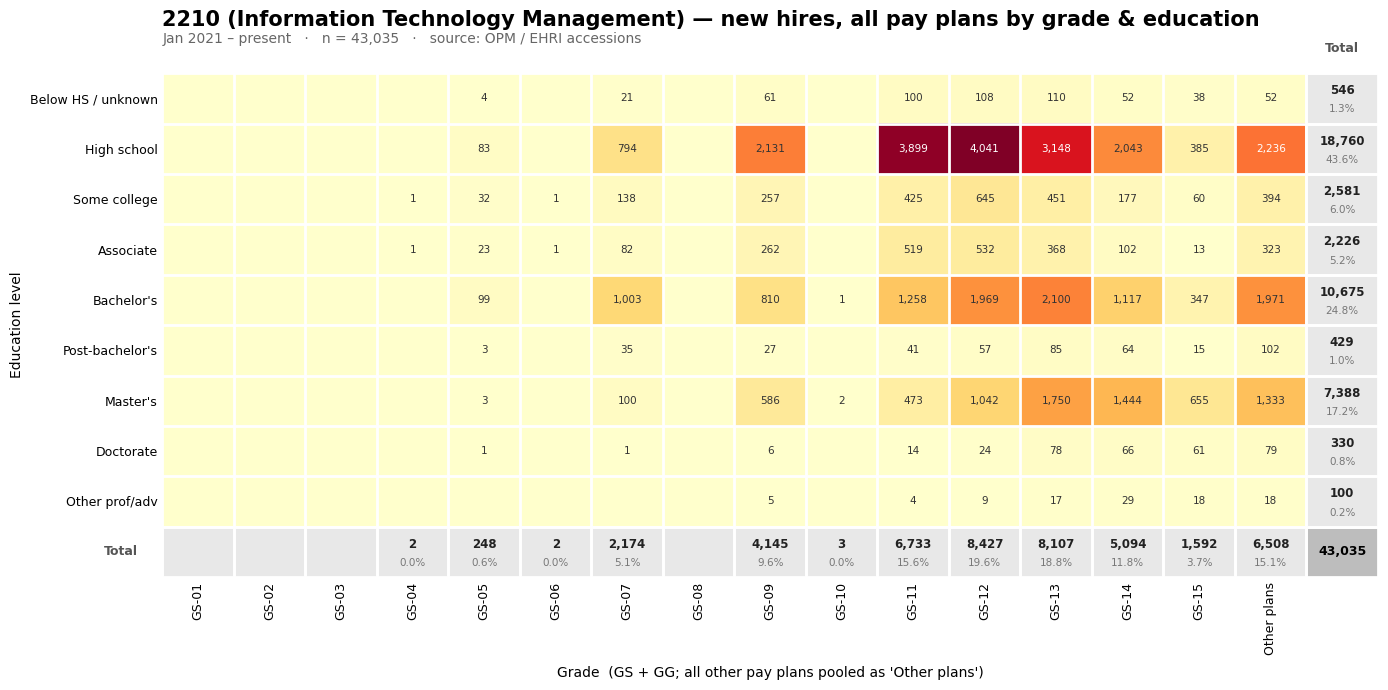

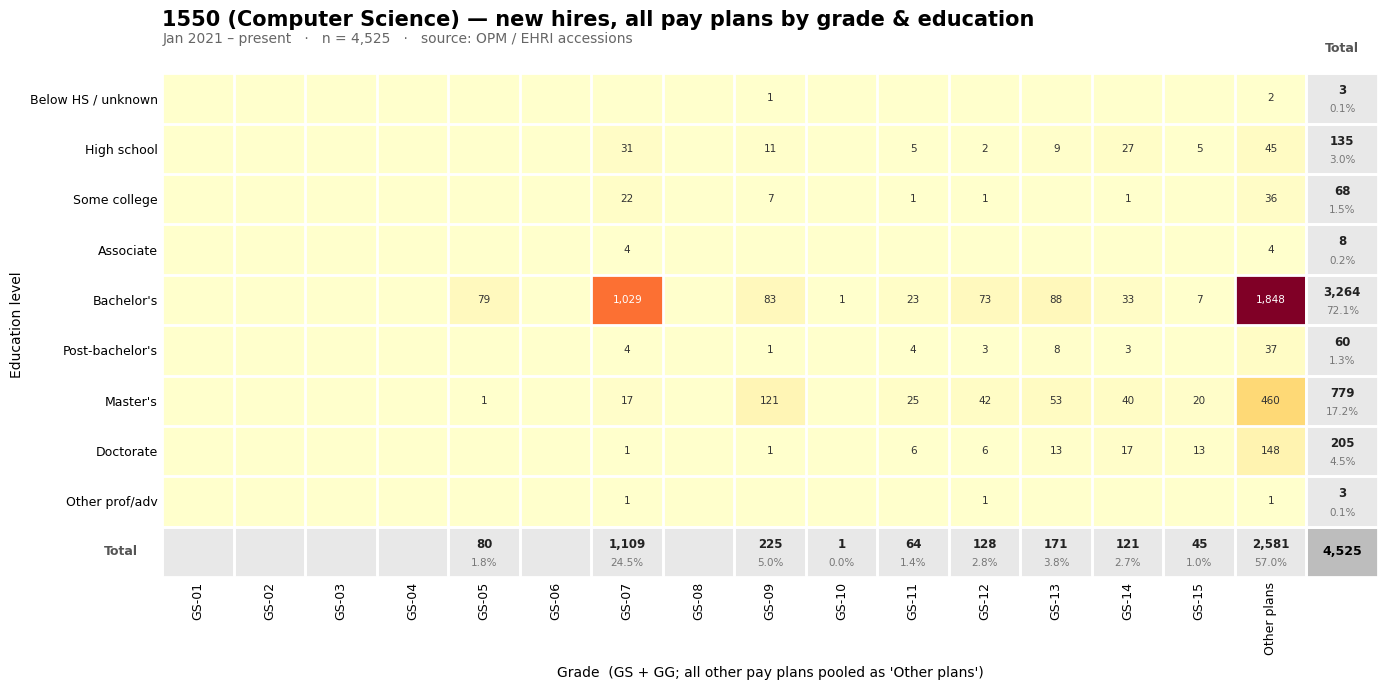

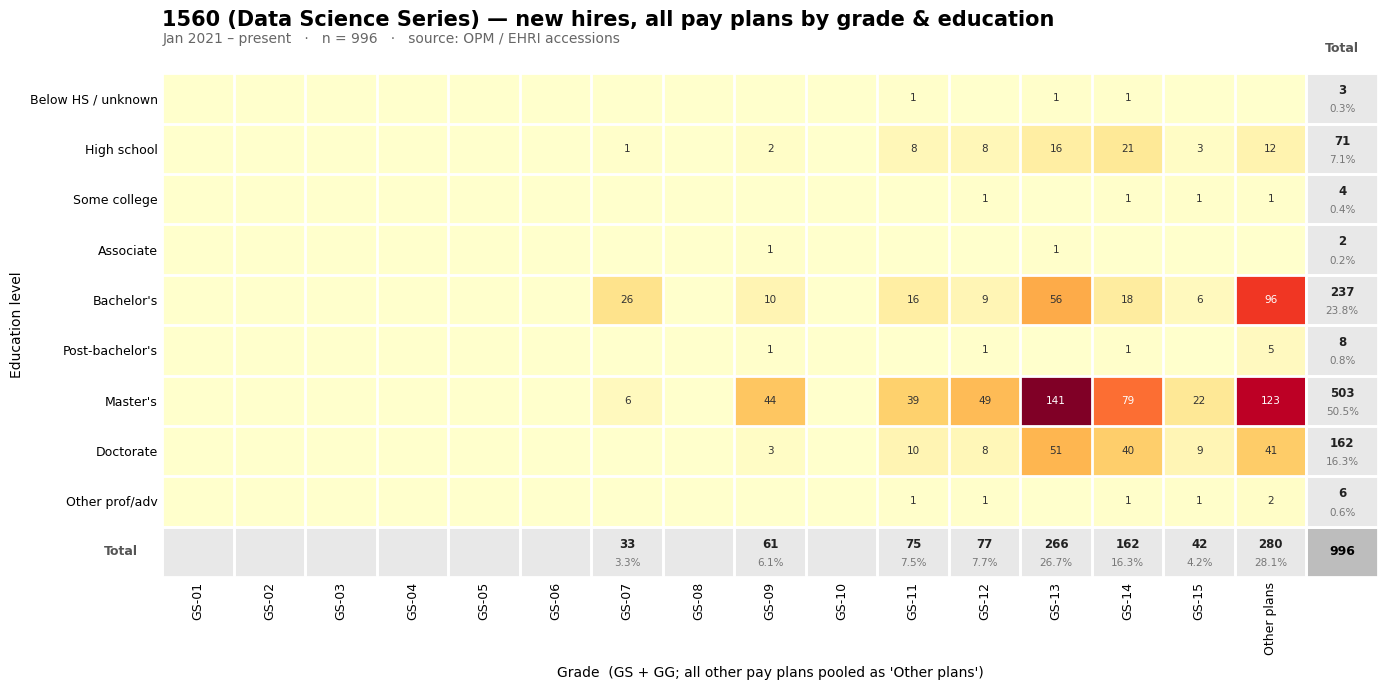

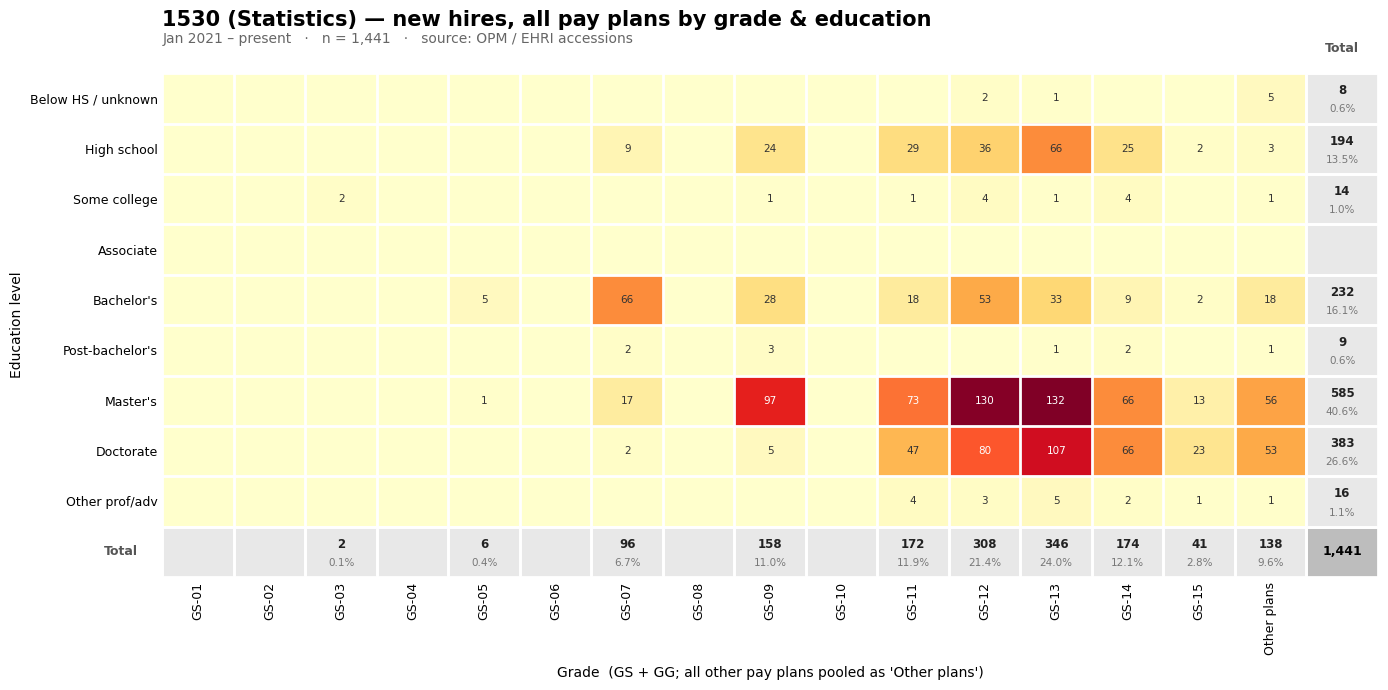

In [7]:
for code in SERIES:
    accession_heatmap(code, all_plans=True)

### Qualifying-cell staircase, full grade scale (GS + GG)

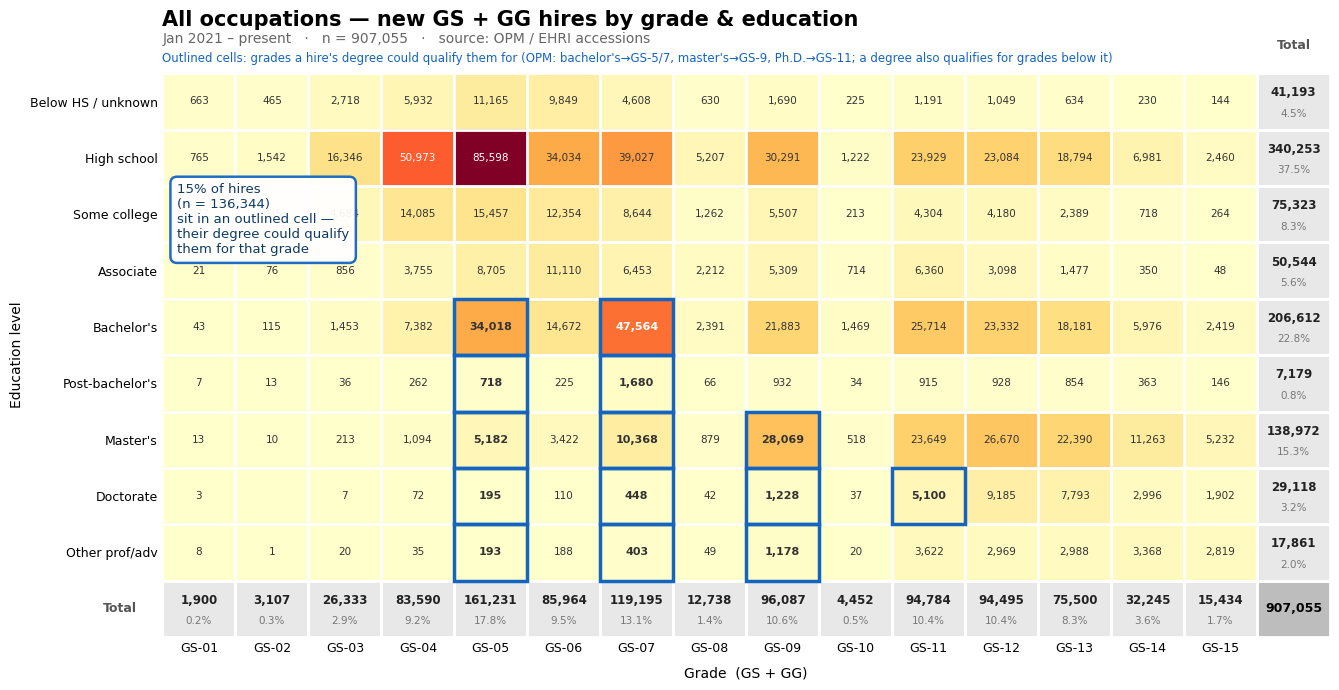

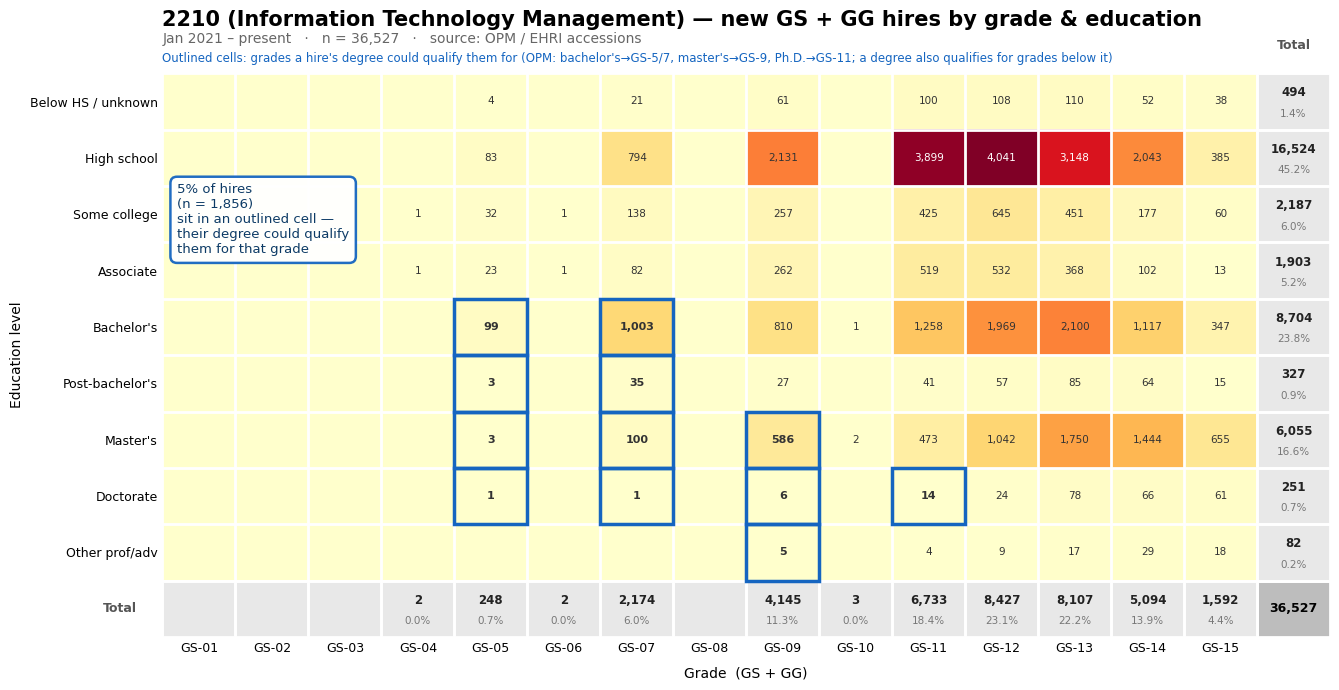

In [8]:
accession_heatmap(pay_plans="gs+gg", highlight_quals=True)            # all occupations
accession_heatmap("2210", pay_plans="gs+gg", highlight_quals=True);   # IT Management

## Save figures to disk (optional)

wrote heatmap_overall_simple.png


wrote heatmap_2210_simple.png


wrote heatmap_2210.png


wrote heatmap_2210_allplans.png


wrote heatmap_1550.png


...

wrote heatmap_1560_allplans.png


wrote heatmap_1530.png


wrote heatmap_1530_allplans.png


wrote heatmap_overall_gsgg_quals.png


wrote heatmap_2210_gsgg_quals.png


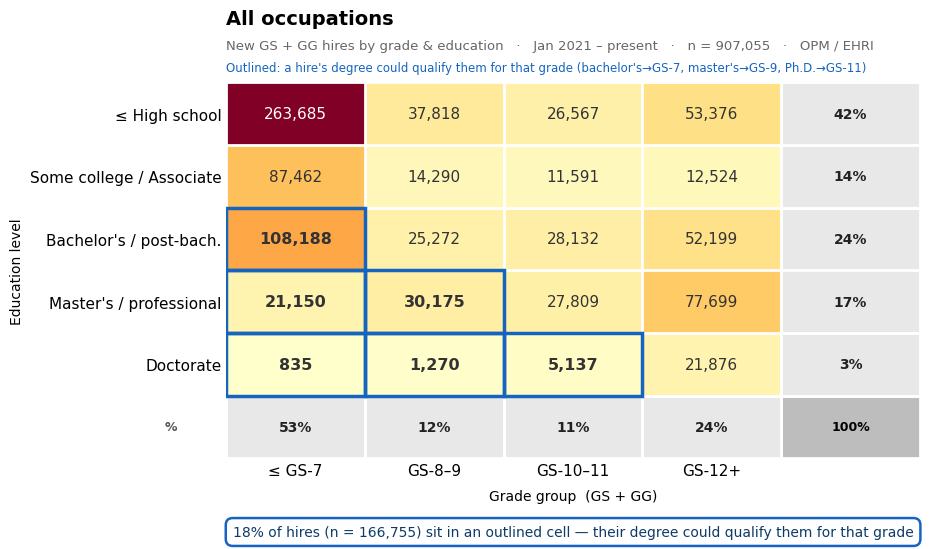

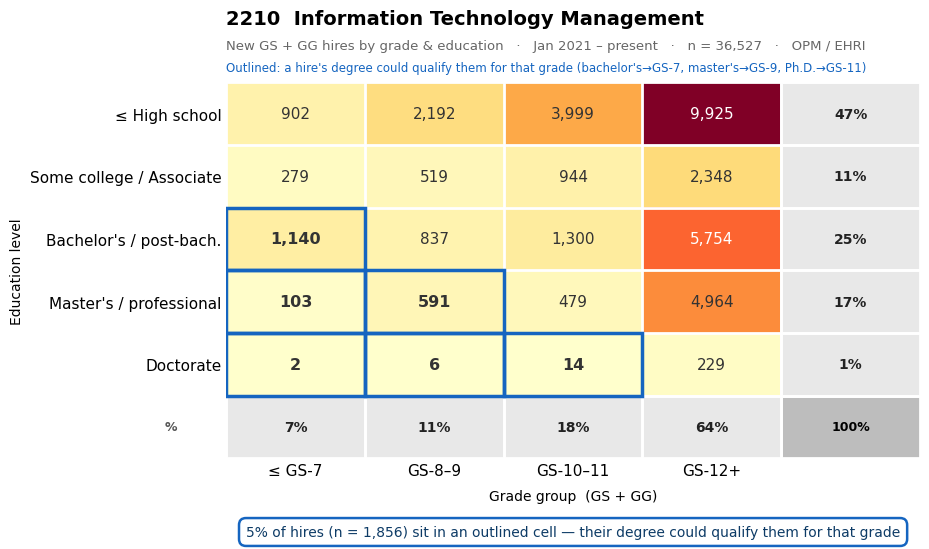

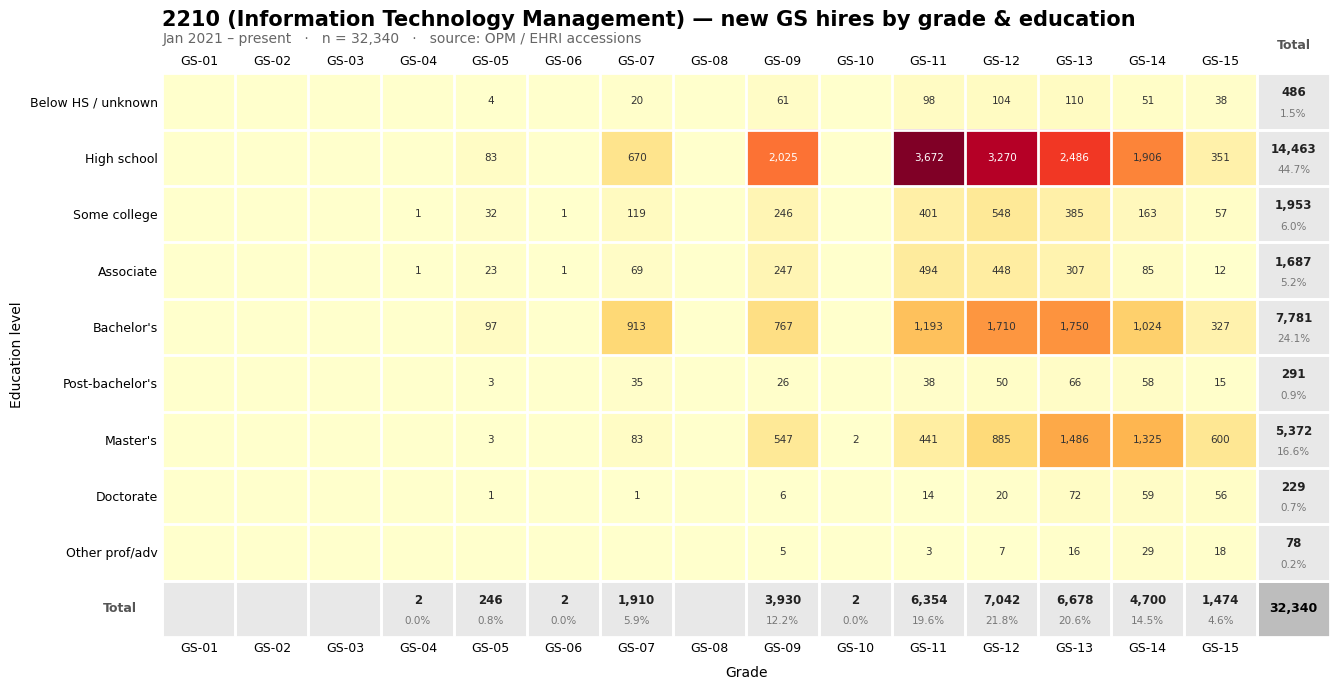

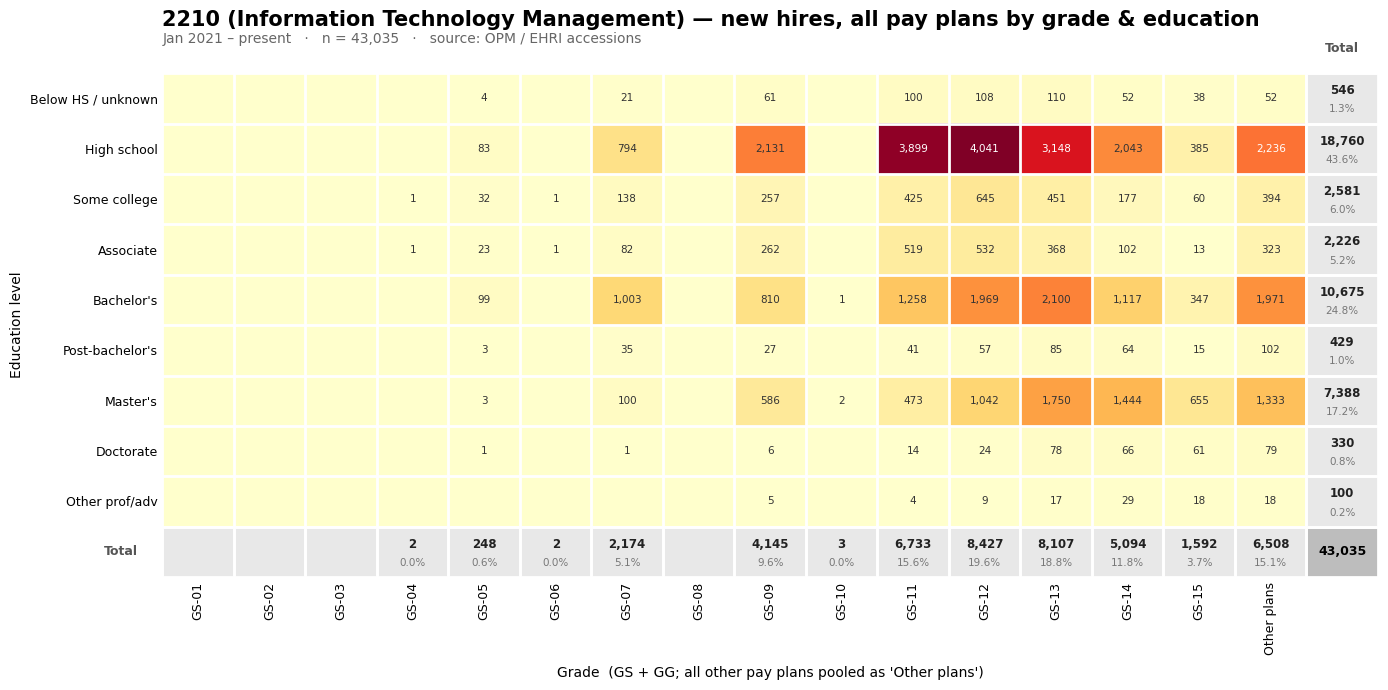

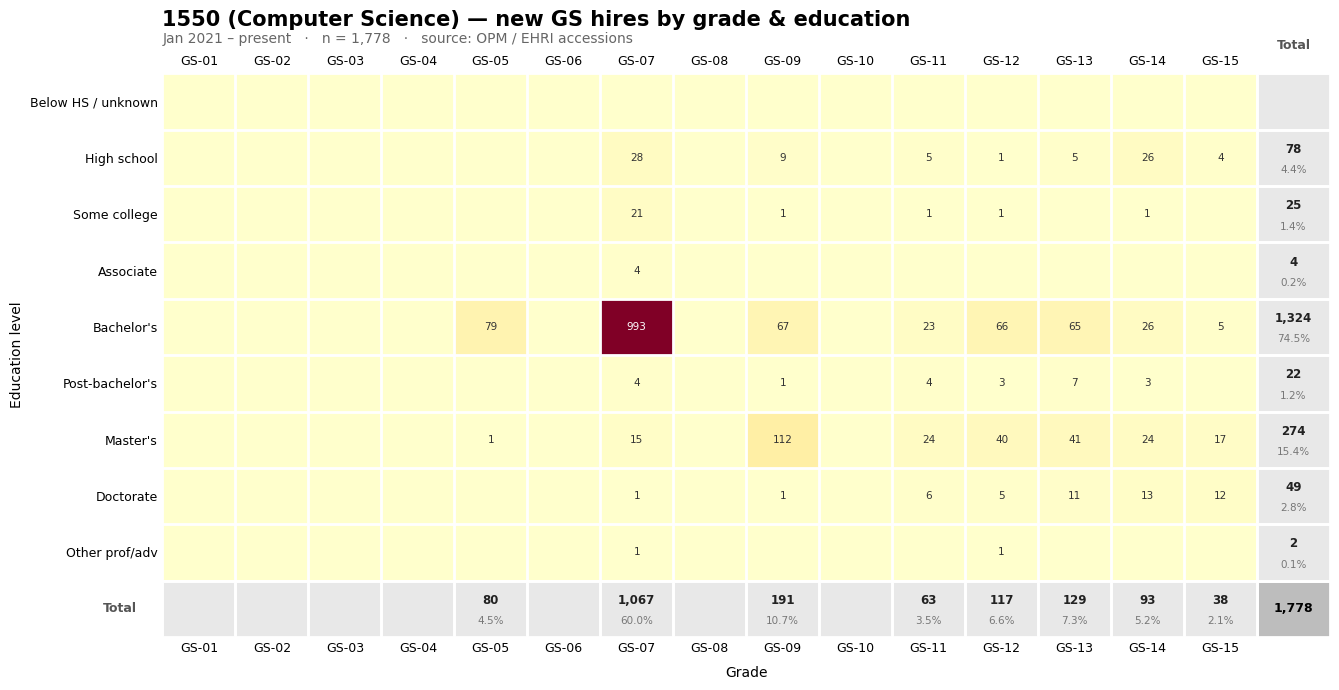

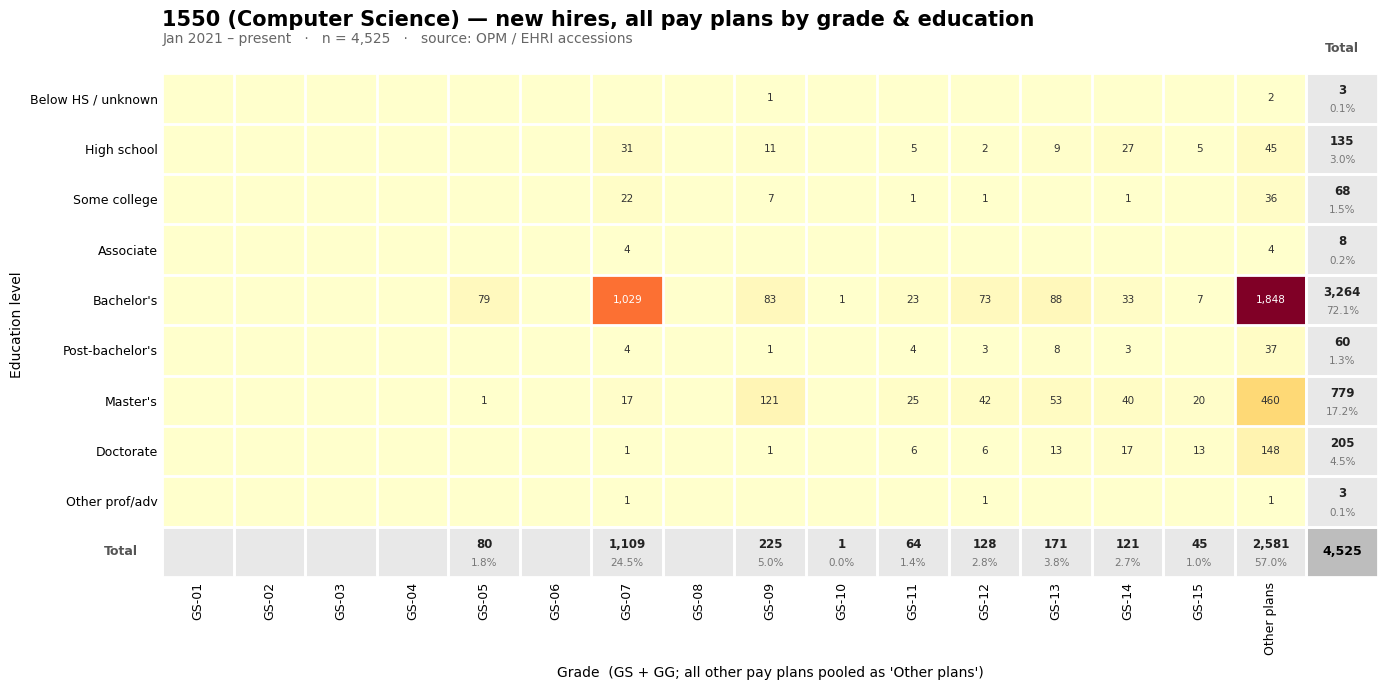

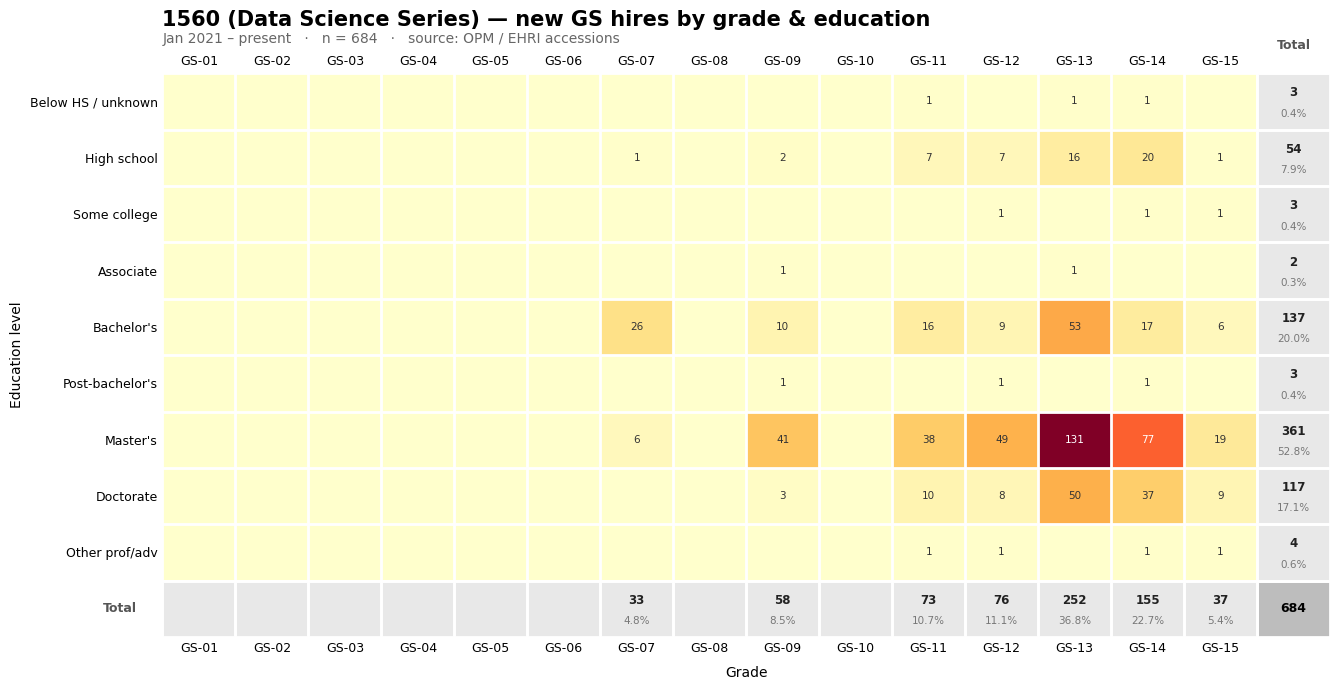

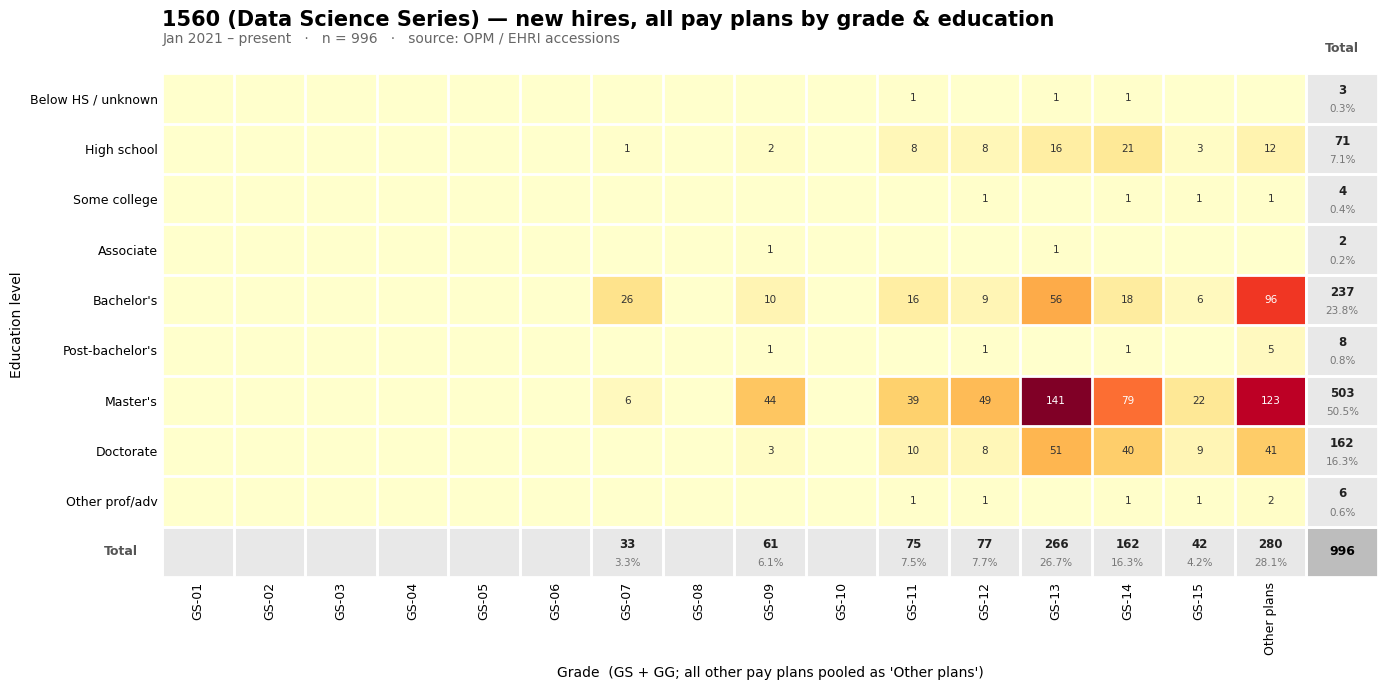

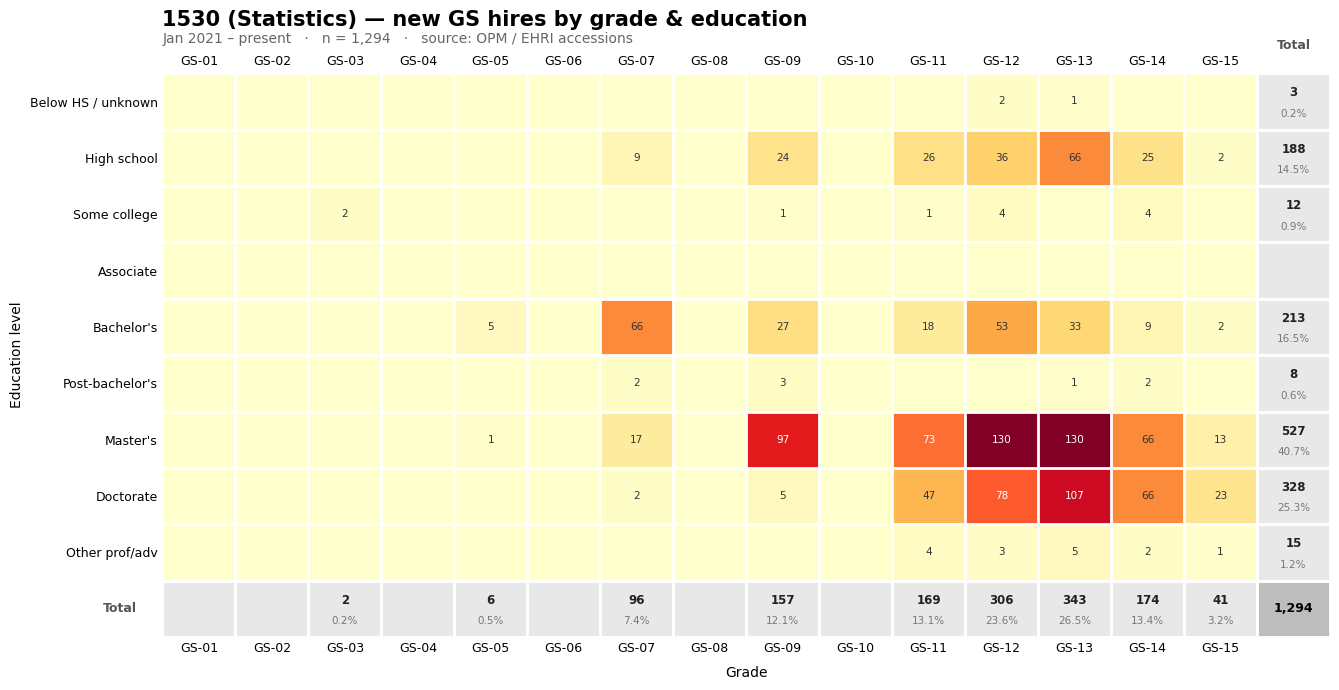

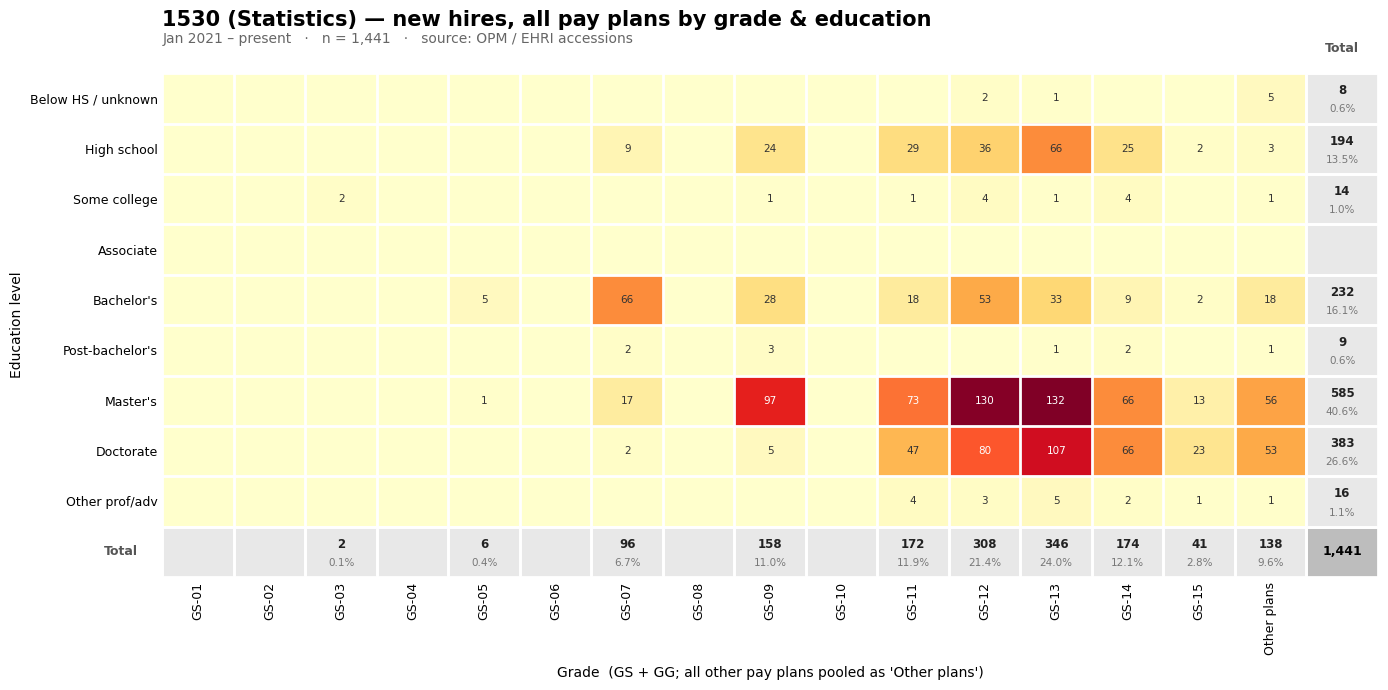

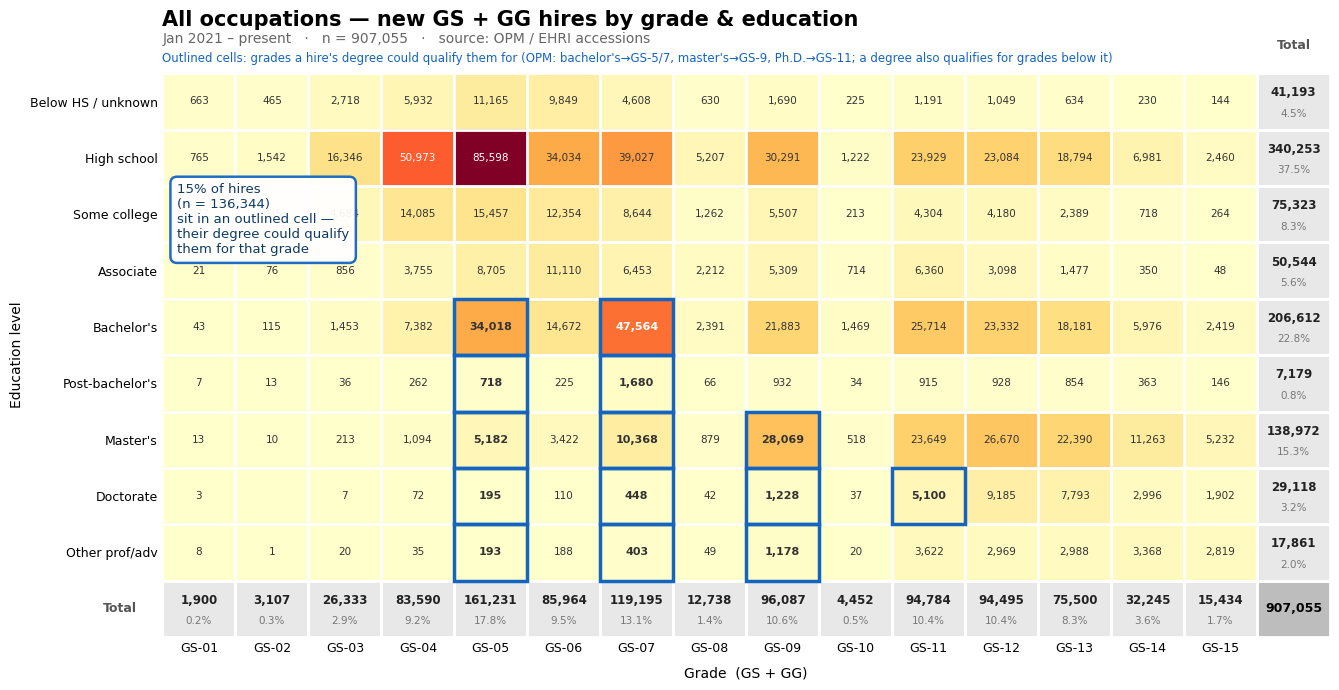

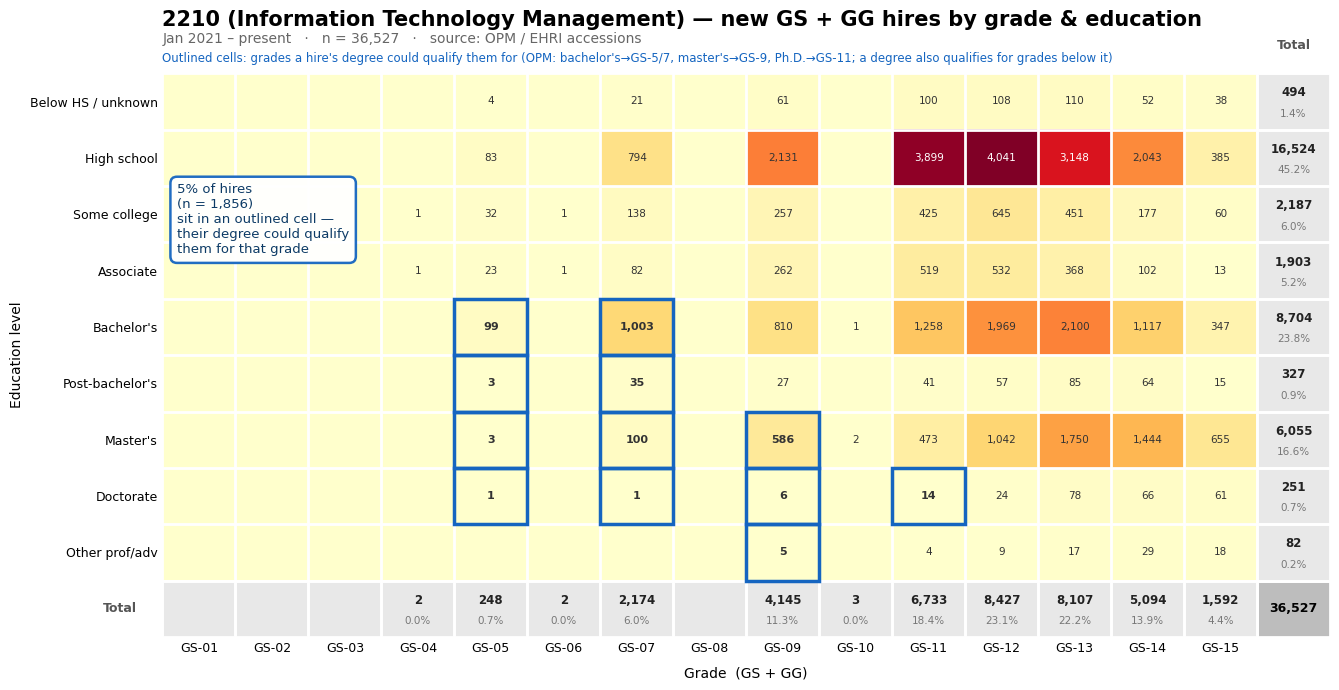

In [9]:
# simplified (publication) figures
accession_heatmap(simple=True, highlight_quals=True, out="heatmap_overall_simple.png")
accession_heatmap("2210", simple=True, highlight_quals=True, out="heatmap_2210_simple.png")

# detailed figures
for code in SERIES:
    accession_heatmap(code, save=True)
    accession_heatmap(code, all_plans=True, save=True)
accession_heatmap(pay_plans="gs+gg", highlight_quals=True, out="heatmap_overall_gsgg_quals.png")
accession_heatmap("2210", pay_plans="gs+gg", highlight_quals=True, out="heatmap_2210_gsgg_quals.png");

## Methodology & caveats

- **Unit:** OPM/EHRI *accessions* = personnel actions that add an employee to the federal workforce (new hires, transfers in). Each parquet row is pre-aggregated; figures use `SUM(count)`.
- **Window:** accession effective month `>= 202101` (Jan 2021). Change `START_MONTH` in `ehri_heatmaps.py` to adjust.
- **Education** is self-reported `education_level_code`. For series with no positive degree requirement (e.g. 2210), "≤ High school" reflects the qualifying education recorded, not necessarily the employee's highest attainment.
- **Grade:** `pay_plans="gs"` is the General Schedule only; `"gs+gg"` adds GG (same scale); `"all"` pools every other pay plan into one "Other plans" column. `simple=True` collapses to 4 grade groups (≤GS-7, GS-8–9, GS-10–11, GS-12+) and 5 education buckets, folding empty low grades in.
- **Qualifying-cell outlines** (`highlight_quals=True`) mark cells where a hire's degree could qualify them for that grade under OPM's group-coverage standard (bachelor's→GS-5/7, master's→GS-9, Ph.D.→GS-11), with each degree also covering the lower entry grades (the staircase). The "master's / professional" bucket folds in first-professional and sixth-year degrees, credited at GS-9. The box sums those cells as a share of all hires shown. They flag where a degree *could* be the basis of qualification; they don't prove it was, and they exclude experience-based qualification.
- **Latest months** are revised by OPM over time; re-running picks up the newest published version of each month automatically.